In [1]:
import sys, os
import glob
import json
import random

os.environ["TORCH_COMPILE_DISABLE"] = "1"

import torch
torch.set_default_dtype(torch.float64)
torch.set_default_device('cpu')
torch.set_printoptions(precision=8)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.ffxml import ForceFieldXML
from cmm.units import HARTREE2KCAL
from cmm.develop.data import EdaData, EspData, DipoleData, PolarizabilityData, slice_data
from cmm.develop.optimize import Trainer, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.report import report_eda_cluster, report_dipos, report_esp, report_eda_scan
from cmm.develop.extract_params import  extract_multipoles

In [2]:
data_path = "/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water"
eda_data = [
    #EdaData.from_csv_file(f'{data_path}/ion_water_scans/h2o_f_scan.pdb', f'{data_path}/ion_water_scans/h2o_f_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/aimd/h2o_li_aimd.pdb', f'{data_path}/aimd/h2o_li_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_na_aimd.pdb', f'{data_path}/aimd/h2o_na_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_k_aimd.pdb', f'{data_path}/aimd/h2o_k_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_rb_aimd.pdb', f'{data_path}/aimd/h2o_rb_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_cs_aimd.pdb', f'{data_path}/aimd/h2o_cs_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_mg_aimd.pdb', f'{data_path}/aimd/h2o_mg_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_ca_aimd.pdb', f'{data_path}/aimd/h2o_ca_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_f_aimd.pdb', f'{data_path}/aimd/h2o_f_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_cl_aimd.pdb', f'{data_path}/aimd/h2o_cl_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_br_aimd.pdb', f'{data_path}/aimd/h2o_br_aimd.csv'),
    EdaData.from_csv_file(f'{data_path}/aimd/h2o_i_aimd.pdb', f'{data_path}/aimd/h2o_i_aimd.csv'),
    
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/li_f_scan.pdb', f'{data_path}/ion_ion_scans/li_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/li_cl_scan.pdb', f'{data_path}/ion_ion_scans/li_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/li_br_scan.pdb', f'{data_path}/ion_ion_scans/li_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/li_i_scan.pdb', f'{data_path}/ion_ion_scans/li_i_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/na_f_scan.pdb', f'{data_path}/ion_ion_scans/na_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/na_cl_scan.pdb', f'{data_path}/ion_ion_scans/na_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/na_br_scan.pdb', f'{data_path}/ion_ion_scans/na_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/na_i_scan.pdb', f'{data_path}/ion_ion_scans/na_i_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/k_f_scan.pdb', f'{data_path}/ion_ion_scans/k_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/k_cl_scan.pdb', f'{data_path}/ion_ion_scans/k_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/k_br_scan.pdb', f'{data_path}/ion_ion_scans/k_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/k_i_scan.pdb', f'{data_path}/ion_ion_scans/k_i_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/rb_f_scan.pdb', f'{data_path}/ion_ion_scans/rb_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/rb_cl_scan.pdb', f'{data_path}/ion_ion_scans/rb_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/rb_br_scan.pdb', f'{data_path}/ion_ion_scans/rb_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/rb_i_scan.pdb', f'{data_path}/ion_ion_scans/rb_i_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/cs_f_scan.pdb', f'{data_path}/ion_ion_scans/cs_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/cs_cl_scan.pdb', f'{data_path}/ion_ion_scans/cs_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/cs_br_scan.pdb', f'{data_path}/ion_ion_scans/cs_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/cs_i_scan.pdb', f'{data_path}/ion_ion_scans/cs_i_scan.csv'),

    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/mg_f_scan.pdb', f'{data_path}/ion_ion_scans/mg_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/mg_cl_scan.pdb', f'{data_path}/ion_ion_scans/mg_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/mg_br_scan.pdb', f'{data_path}/ion_ion_scans/mg_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/mg_i_scan.pdb', f'{data_path}/ion_ion_scans/mg_i_scan.csv'),
 
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/ca_f_scan.pdb', f'{data_path}/ion_ion_scans/ca_f_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/ca_cl_scan.pdb', f'{data_path}/ion_ion_scans/ca_cl_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/ca_br_scan.pdb', f'{data_path}/ion_ion_scans/ca_br_scan.csv'),
    EdaData.from_csv_file(f'{data_path}/ion_ion_scans/ca_i_scan.pdb', f'{data_path}/ion_ion_scans/ca_i_scan.csv'),
]

In [3]:
from cmm.develop.optimize import sqrt_weight_func

# HERE: Need to make it possible to fit only the pair parameters
# while leaving the atomic params unchanged.

ff = ForceFieldXML('ion_water_refit.xml', requires_grad=True)
optimizer = Optimizer(
    ff,
    freeze_water=True,
    opt_params=[
        'b_pauli',
        'b_elec',
        'b_disp',
        'b_ct',
        'b_xpol',
        'alpha_damp_exponent',
    ],
    optim='adam',
    fit_pair_params_only=True,
    lr=0.005,
    l2=1000.0,
    l2_params=[
        # 'Z', 
        # 'alpha_xx', 'alpha_yy', 'alpha_zz'
        # 'j_cf', 'j_cf_bb', 'j_cf_angle',
        # 'c0', 'dx', 'dy', 'dz'
        # 'Kdipo_pauli', 'Kquad_pauli',
        # 'q_pauli', 
        # 'b_pauli'
        # "b_xpol", 
        # 'Kdipo_xpol', 'Kquad_xpol'
    ],
    #additional_positive_constraints=['q_xpol'],
    # freeze_types=['hc.moh','c.moh']
)

trainer = Trainer(
    ff, 
    optimizer, 
    target_weights={'EdaData':1},
    eda_weights={'perm_elec': 1.0, 'int': 1.0, 'pauli': 1.0, 'disp': 1.0, 'pol': 1.0, 'ct': 1.0},
    weight_func=None
)

for key in optimizer.opt_params:
    print(key, optimizer.opt_params[key][optimizer.masks[key]].numpy(force=True).tolist())

2025-09-30 13:04:12,576 - INFO - The following parameters are being optimized: 
ChargePenetration/Pair/b_elec
PauliRepulsion/Pair/b_pauli
ExchangePolarization/Pair/b_xpol
Dispersion/Pair/b_disp
ChargeTransfer/Pair/b_ct
2025-09-30 13:04:12,577 - INFO - The following parameters are enforced to be positive during optimization: 
ChargePenetration/Pair/b_elec
PauliRepulsion/Pair/b_pauli
ExchangePolarization/Pair/b_xpol
Dispersion/Pair/b_disp
ChargeTransfer/Pair/b_ct


In [4]:
train_datas = []
for data in eda_data:
    train_datas.append(data)

#_ = trainer.train(train_datas, 500)

In [5]:
_ = ff.save('ion_water_refit_2.xml')

/home/heindelj/miniforge3/envs/pycmm/lib/python3.12/site-packages/torch/nested/__init__.py:226: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  return _nested.nested_tensor(


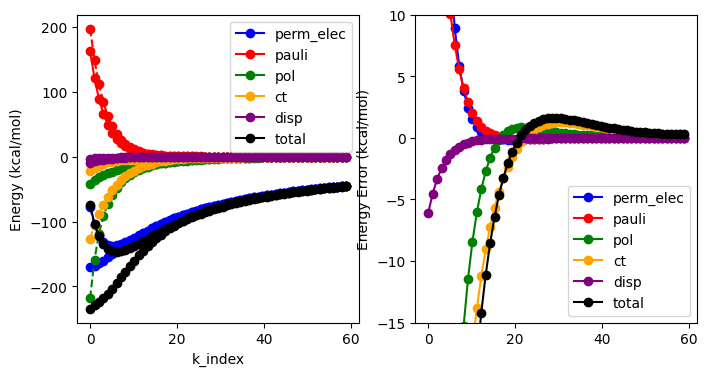

In [6]:
n_points = eda_data[13].coords.size(0)
fig1 = report_eda_scan(trainer, eda_data[13], xdata=np.linspace(0, n_points, n_points), ymin=-15, ymax=10)

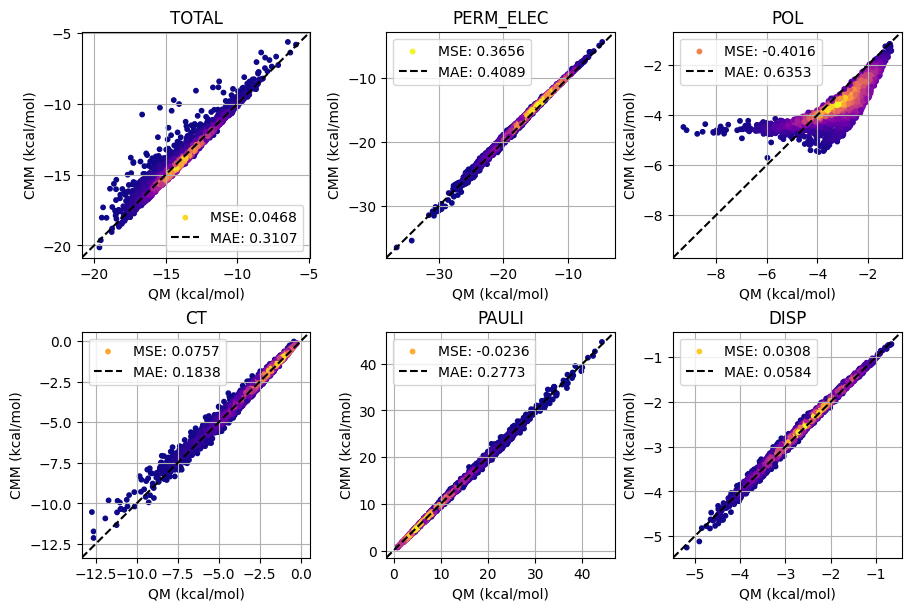

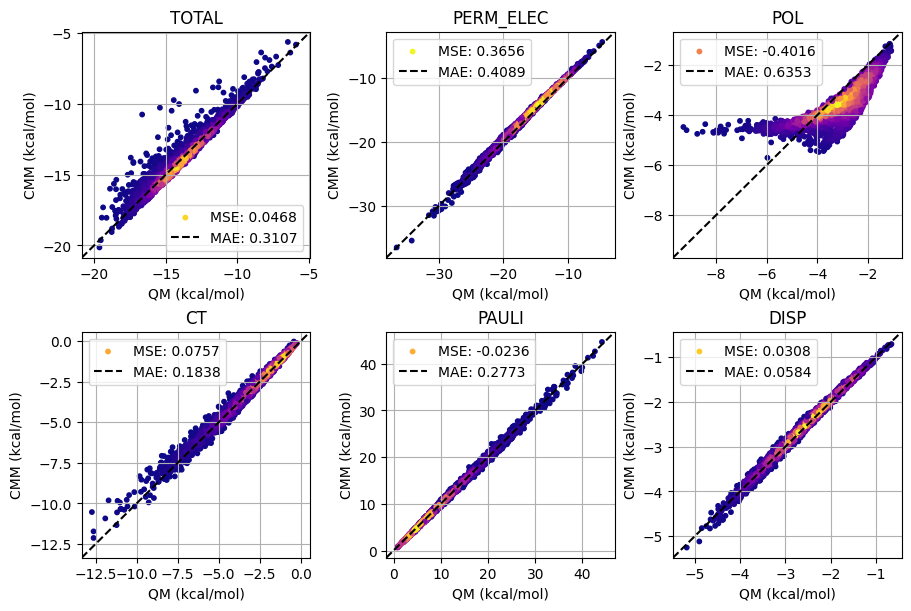

In [7]:
report_eda_cluster(trainer, eda_data[8])